### Sum of a Bivariate Normal

Let us define a bivariate Gaussian using a mean vector and covariance matrix,

$$
\boldsymbol{\mu} = \begin{pmatrix}\mu_x \\ \mu_y\end{pmatrix},
\qquad
\Sigma = \begin{pmatrix}
\sigma_x^2 & \rho\,\sigma_x\sigma_y \\
\rho\,\sigma_x\sigma_y & \sigma_y^2
\end{pmatrix}.
$$

We again consider the derived random variable

$$
S = X + Y.
$$

For a multivariate Gaussian, any linear combination is again Gaussian. Therefore,

$$
S \sim \mathcal{N}(\mu_S, \sigma_S^2),
$$

with

$$
\mu_S = \mu_x + \mu_y,
\qquad
\sigma_S^2 = \sigma_x^2 + \sigma_y^2 + 2\rho\,\sigma_x\sigma_y.
$$

The first code cell below plots the analytic PDFs of $X$, $Y$, and $S=X+Y$ in one figure.
The second code cell varies the correlation coefficient $\rho$ and shows $\mathrm{Var}(S)$, $\mathrm{Var}(X)$, and $\mathrm{Var}(Y)$.

Mean vector mu =
[0. 1.]
Covariance matrix Sigma =
[[1.44  0.576]
 [0.576 0.64 ]]
Correlation coefficient rho = 0.6
Analytic mean of S = X + Y: 1.0
Analytic variance of S = X + Y: 3.232


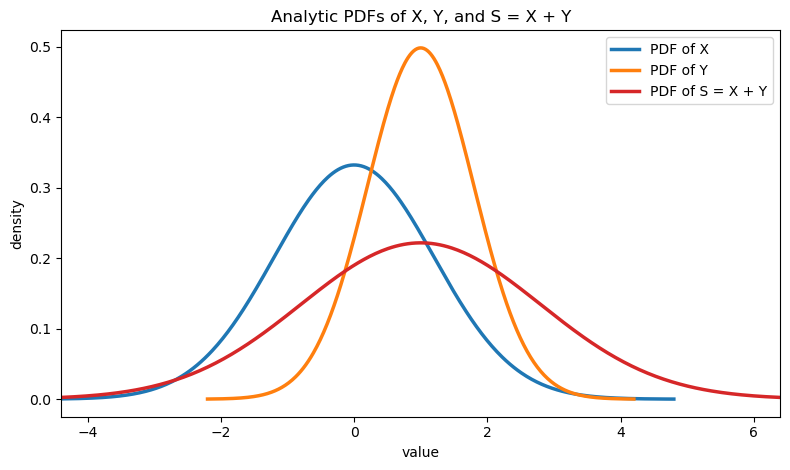

In [17]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([0.0, 1.0])
sigma_x = 1.2
sigma_y = 0.8
rho = 0.6

Sigma = np.array([
    [sigma_x**2, rho * sigma_x * sigma_y],
    [rho * sigma_x * sigma_y, sigma_y**2],
])

# Analytic marginal PDFs of X and Y.
x_grid = np.linspace(mu[0] - 4 * sigma_x, mu[0] + 4 * sigma_x, 500)
y_grid = np.linspace(mu[1] - 4 * sigma_y, mu[1] + 4 * sigma_y, 500)
pdf_x = (1.0 / (sigma_x * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mu[0]) / sigma_x) ** 2)
pdf_y = (1.0 / (sigma_y * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((y_grid - mu[1]) / sigma_y) ** 2)

# Analytic mean and variance of S = X + Y.
mu_s = np.sum(mu)
var_s = sigma_x**2 + sigma_y**2 + 2 * rho * sigma_x * sigma_y
sigma_s = np.sqrt(var_s)

# Analytic PDF of S.
s_grid = np.linspace(mu_s - 5 * sigma_s, mu_s + 5 * sigma_s, 600)
pdf_s = (1.0 / (sigma_s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((s_grid - mu_s) / sigma_s) ** 2)

print('Mean vector mu =')
print(mu)
print('Covariance matrix Sigma =')
print(Sigma)
print('Correlation coefficient rho =', rho)
print('Analytic mean of S = X + Y:', mu_s)
print('Analytic variance of S = X + Y:', var_s)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(x_grid, pdf_x, lw=2.5, color='tab:blue', label='PDF of X')
ax.plot(y_grid, pdf_y, lw=2.5, color='tab:orange', label='PDF of Y')
ax.plot(s_grid, pdf_s, lw=2.5, color='tab:red', label='PDF of S = X + Y')
ax.set_title('Analytic PDFs of X, Y, and S = X + Y')
ax.set_xlabel('value')
ax.set_ylabel('density')
ax.legend()
plt.xlim(mu_s - 3 * sigma_s, mu_s + 3 * sigma_s)
plt.tight_layout()
plt.show()

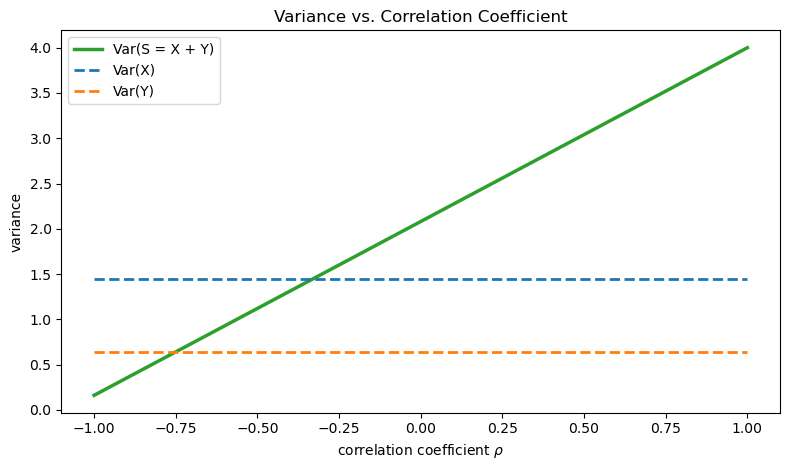

In [18]:
# Vary correlation and compare variances of S, X, and Y.
rho_grid = np.linspace(-1, 1, 400)
var_x_rho = np.full_like(rho_grid, sigma_x**2)
var_y_rho = np.full_like(rho_grid, sigma_y**2)
var_s_rho = sigma_x**2 + sigma_y**2 + 2 * rho_grid * sigma_x * sigma_y

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(rho_grid, var_s_rho, lw=2.5, color='tab:green', label='Var(S = X + Y)')
ax.plot(rho_grid, var_x_rho, lw=2.0, color='tab:blue', linestyle='--', label='Var(X)')
ax.plot(rho_grid, var_y_rho, lw=2.0, color='tab:orange', linestyle='--', label='Var(Y)')
ax.set_title('Variance vs. Correlation Coefficient')
ax.set_xlabel(r'correlation coefficient $\rho$')
ax.set_ylabel('variance')
ax.legend()
plt.tight_layout()
plt.show()